# IrriGator — Full End-to-End Pipeline

Central notebook covering **every block** from raw data to irrigation recommendation.

| Block | What | Data source | Run frequency |
|-------|------|-------------|---------------|
| 0 | Data ingestion | ERA5-Land (France-wide), COMEPHORE, Sentinel-2, soil, DEM | Once (historical archive) |
| 1 | Static layers | EU-SoilHydroGrids, IGN DEM | Once per parcel |
| 2 | Atmospheric forcing | ERA5-Land daily → parcel extraction | Once (cache), then per parcel |
| 3+4 | Simulation | Water balance + crop growth ACQUACROP | Daily |
| 5a | Short-term forecast | AROME (0-48h) + IFS ENS (0-15d) → ensemble | Daily |
| 5b | Seasonal outlook | SEAS5 → PCA analog → ensemble water balance | Monthly |
| 6 | Decision | Ensemble stress → irrigation recommendation | Daily |

**Architecture change:** ERA5-Land is now downloaded once for all of metropolitan
France (41°N–51.5°N, 6°W–10°E). Any new parcel is served from this cache
without additional API calls. AROME and IFS ENS already work the same way.

---
## Configuration — set your "today" and paths here

In [1]:
import logging
import os
from datetime import date
from pathlib import Path
from datetime import timedelta

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date(2025, 9, 1)          # the date we treat as "today"
# TODAY = date.today()
SIMULATION_START = date(2025, 1, 1) # start of the growing season simulation
LAST_IRRIGATION = None              # date of last irrigation, or None for rainfed
RUN_SEAS5 = False                   # set True to include seasonal outlook (monthly run)
PLOT_SEAS5_PCA = True  # diagnostic ERA5-vs-SEAS5 PC1/PC2 figure
FETCH_SEAS5_HINDCASTS = False  # one-time: fetch 1993-2016 hindcasts for current init month
REFRESH_SEAS5 = False  # set True once if an old 2-variable SEAS5 cache exists
RUN_YIELD_OPTIMIZER = False  # requires RUN_SEAS5=True for a harvest-horizon objective
RUN_BRANCH_EQUIVALENCE_TEST = False  # compare private branching vs full AquaCrop on 3 members
RUN_HISTORICAL_OPTIMIZER = False  # retrospective fixed-date dose optimization

SHIFT = 0                           # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")                # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")     # daily aggregates, cached results
STATIC_DIR = Path("data/static")           # static ERA5-Land data (soil, land cover, etc.)


# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}_no_irr.yaml"
PARCEL_CONFIG_IRR = f"configs/parcels/billac_{TODAY.year}.yaml"
PARCEL_CONFIG_OPT = f"configs/parcels/billac_{TODAY.year}_test_irr.yaml"

PARCEL_CONFIG2 = f"configs/parcels/guide_{TODAY.year}_no_irr.yaml"


HISTORICAL_PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}.yaml"
HISTORICAL_PARCEL_BIS_CONFIG = f"configs/parcels/guide_{TODAY.year}.yaml"

CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")

Repo root: /home/mbaldacchino/code/IrriGator
Today:     2025-09-01
Raw dir:   data/raw
Processed: data/processed


# End-to-End Forecast Pipeline

In [2]:
from irrigator.config import load_region_config, load_parcel_config
from irrigator.static_layers.soil import get_soil_profile
from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation
from irrigator.atmospheric.era5_processor import (
    load_daily,
    process_era5_to_daily,
    save_daily,
)
from irrigator.atmospheric.forcing import extract_parcel_forcing

from irrigator.water_balance.aquacrop_adapter import run_aquacrop
import pandas as pd
from irrigator.water_balance.soil_water_content import (
    build_initial_soil_water_profile_from_era5_land,
)
from irrigator.water_balance.yield_optimizer import (
        YieldConstraint,
        optimize_operational_irrigation,
)
from datetime import datetime
from irrigator.forecasts.historical import get_historical_forecast
from irrigator.ingestion.hres_historical_client import load_hres_run


def retrospective_pipeline(start_date, end_date, parcel_path, config,*, sim_start = SIMULATION_START,
                            require_harvest_horizon : bool = False, silent : bool = True):
    cfg = load_region_config(config)
    parcel_no_irr = load_parcel_config(parcel_path) # parcel without any irrigation
    soil = get_soil_profile(cfg, parcel_no_irr)
    terrain = get_terrain_params(cfg, parcel_no_irr)
    terrain.era5_elevation_m = get_era5_elevation(cfg, parcel_no_irr)
    current = start_date

    # 0 Initialize

    initial_soil_water_parcel = build_initial_soil_water_profile_from_era5_land(
        soil_profile=soil,
        parcel_profile=parcel_no_irr,
        date=sim_start,
        processed_dir=PROCESSED_DIR,
        raw_dir=RAW_DIR,
        static_dir=STATIC_DIR,
    )

    # 1 atmospheric forcing 

    era5_daily = load_daily(processed_dir=PROCESSED_DIR, year=sim_start.year)
    forcing = extract_parcel_forcing(era5_daily, parcel_no_irr, terrain)

    parcel = parcel_no_irr # Initialize without any irrigation plan
    # Start forecast loop strategy
    while current <= end_date:
        print(current)

        # 2 Historical simulation
        historical_forcing = forcing.slice(SIMULATION_START, current - timedelta(days=1))

        # 3 Get historical forecasts

        hist_forecast = get_historical_forecast(
            issue_date=current,
            parcel=parcel,
            terrain=terrain,
            silent=silent,
        )

        # X Optimize irrigation plan
        
        # If planned to use previous_plan
        previous_plan = parcel.irrigation_log

        realized_log = [
            event
            for event in parcel.irrigation_log
            if datetime.strptime(event["date"], "%Y-%m-%d").date() <= current
        ]

        parcel_for_optimizer = parcel.replace_irrigation(
            irrigation_log=realized_log,
        )
    
        yield_plan = optimize_operational_irrigation(
            historical_forcing=historical_forcing,
            arome_forcing=hist_forecast.hres_forcing,
            future_member_forcings=hist_forecast.ifs_member_forcings,
            parcel=parcel_for_optimizer,
            terrain=terrain,
            soil_profile=soil,
            today=current,
            sim_start=SIMULATION_START,
            previous_plan=previous_plan,
            commitment_days=2,
            constraint=YieldConstraint(
                # Used once partial yield becomes meaningful,
                # and exclusively when forecast reaches harvest.
                max_relative_loss=0.01,
                absolute_tolerance_t_ha=0.01,
                # Partial-horizon crop-state constraints.
                max_relative_biomass_loss=0.02,
                max_relative_canopy_loss=0.02,
                absolute_biomass_tolerance_t_ha=0.05,
                absolute_canopy_tolerance=0.01,
                min_member_probability=0.85,
            ),
            # New default timing mechanism
            stress_trigger_mode="dynamic_depletion",
            stress_trigger_process="auto",
            stress_trigger_margin_fraction=0.0,
            trigger_quantile=0.25,
            irrigation_lead_days=1,
            dose_resolution_mm=2.0,
            max_events=100,
            n_workers=10,
            require_harvest_horizon=False,
            initial_soil_water_profile=initial_soil_water_parcel,
        )
        yield_log = yield_plan.to_irrigation_log()
        print(parcel)
        parcel = parcel.replace_future_irrigation_event(yield_plan.to_irrigation_log()) if len(yield_log) > 0 else parcel
        print("Parcel changed")
        print(parcel)
        current += timedelta(days=1)
        

    return parcel

from irrigator.config import ParcelConfig
import pandas as pd
import matplotlib.pyplot as plt
from irrigator.water_balance.plot_aquacrop_summary import (
    plot_aquacrop_season,
    summarize_aquacrop_seasons,
)
from irrigator.water_balance.aquacrop_adapter import soil_to_aquacrop
from irrigator.water_balance.aquacrop_adapter import run_aquacrop
import pandas as pd



def compare_irrigation_strategies(parcels : list[ParcelConfig], names, scenario, soil, terrain,sim_start):
    runs = {}
    initial_soil_water_parcel = build_initial_soil_water_profile_from_era5_land(
            soil_profile=soil,
            parcel_profile=parcels[0],
            date=sim_start,
            processed_dir=PROCESSED_DIR,
            raw_dir=RAW_DIR,
            static_dir=STATIC_DIR,
        )
    for idx,parcel in enumerate(parcels):
        era5_daily = load_daily(processed_dir=PROCESSED_DIR, year=sim_start.year)
        forcing = extract_parcel_forcing(era5_daily, parcel, terrain)

        historical_forcing = forcing.slice(SIMULATION_START, TODAY - timedelta(days=1))

        LAST_ERA5_DAY = pd.to_datetime(historical_forcing.dates[-1]).date()

        hist_run = run_aquacrop(
            forcing=historical_forcing,
            parcel=parcel,
            terrain=terrain,
            soil_profile=soil,
            sim_start=SIMULATION_START,
            sim_end=LAST_ERA5_DAY,
            initial_soil_water_profile=initial_soil_water_parcel,
        )

        runs[names[idx]] = {
            "parcel" : parcel.id,
            "scenario" : scenario[idx],
            "crop_growth" : hist_run.crop_growth,
            "water_flux" :  hist_run.water_flux,
            "daily_stress" : hist_run.daily_stress,
            "soil" : soil_to_aquacrop(soil).profile,
            "sim_start" : sim_start,
            "season" : 0,
        }
    

    fig, prepared = plot_aquacrop_season(
        runs,
        figsize=(16, 14),
    )

    # fig.savefig(
    #     "aquacrop_2025_scenarios.png",
    #     dpi=200,
    #     bbox_inches="tight",
    # )

    #  plt.show()


    series_metadata = {
        name: {
            "parcel": data.attrs["parcel"],
            "scenario": data.attrs["scenario"],
        }
        for name, data in prepared.items()
    }

    summary = summarize_aquacrop_seasons(
        prepared,
        series_metadata,
    )

    display(
        summary[
            [
                "parcel",
                "scenario",
                "final_dry_yield_t_ha",
                "potential_dry_yield_t_ha",
                "irrigation_mm",
                "transpiration_mm",
                "deep_percolation_mm",
                "transpiration_stress_days",
                "minimum_tr_over_trpot",
                "maximum_root_zone_depletion_fraction",
            ]
        ].round(2)
    )

    return fig



10:24:58 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
10:24:58 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.


In [3]:
new_parcel = retrospective_pipeline(start_date=date(2025,6,1), end_date=date(2025,9,1), parcel_path=PARCEL_CONFIG, config=REGION_CONFIG)

10:25:05 [irrigator.static_layers.soil] INFO: Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
10:25:05 [irrigator.static_layers.terrain] INFO: Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
10:25:05 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask
10:25:12 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
10:25:12 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
10:25:12 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 365 days, T=[-4.0, 39.0]°C, total precip=nan mm, mean Rs=nan MJ/m²/day
10:25:12 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
10:25:12 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319

2025-06-01


10:25:17 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
10:25:17 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


ParcelConfig(id='billac_001', name='Parcelle Billac - SEP des Pouyades', farmer='Edouard Truffaux', lat=45.38383, lon=0.41508, area_ha=16.3, soil={'source': 'eu_soilhydrogrids', 'geology_class': 'alluvium'}, crop={'type': 'grain_maize', 'planting_date': '2025-04-14', 'expected_harvest': '2025-10-05', 'variety': 'DKC4728', 'maturity_group': 'G3', 'density': 86107, 'emergence_rate': 0.92, 'rooting_depth': {'at_emergence_m': 0.15, 'max_m': 1.5}, 'gdd_thresholds': {'base': 6, 'flowering': 970, 'harvest': 1900}}, irrigation={'system_type': 'sprinkler', 'max_dose_mm': 50, 'min_dose_mm': 15, 'application_rate_mm_h': 8, 'min_interval_days': 7, 'available_days': ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']}, irrigation_log={}, sensors={'probes': [], 'rain_gauge': None})
Parcel changed
ParcelConfig(id='billac_001', name='Parcelle Billac - SEP des Pouyades', farmer='Edouard Truffaux', lat=45.38383, lon=0.41508, area_ha=16.3, soil={'source': 'eu_soilhydrogrids', 'geology_cl

10:25:19 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
10:25:19 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


...

ParcelConfig(id='billac_001', name='Parcelle Billac - SEP des Pouyades', farmer='Edouard Truffaux', lat=45.38383, lon=0.41508, area_ha=16.3, soil={'source': 'eu_soilhydrogrids', 'geology_class': 'alluvium'}, crop={'type': 'grain_maize', 'planting_date': '2025-04-14', 'expected_harvest': '2025-10-05', 'variety': 'DKC4728', 'maturity_group': 'G3', 'density': 86107, 'emergence_rate': 0.92, 'rooting_depth': {'at_emergence_m': 0.15, 'max_m': 1.5}, 'gdd_thresholds': {'base': 6, 'flowering': 970, 'harvest': 1900}}, irrigation={'system_type': 'sprinkler', 'max_dose_mm': 50, 'min_dose_mm': 15, 'application_rate_mm_h': 8, 'min_interval_days': 7, 'available_days': ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']}, irrigation_log=[{'date': '2025-06-02', 'amount_mm': 29.0}, {'date': '2025-06-09', 'amount_mm': 15.0}, {'date': '2025-06-16', 'amount_mm': 15.0}, {'date': '2025-06-23', 'amount_mm': 27.0}, {'date': '2025-06-30', 'amount_mm': 23.0}, {'date': '2025-07-07', 'amount_mm': 

10:31:24 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
10:31:24 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


ParcelConfig(id='billac_001', name='Parcelle Billac - SEP des Pouyades', farmer='Edouard Truffaux', lat=45.38383, lon=0.41508, area_ha=16.3, soil={'source': 'eu_soilhydrogrids', 'geology_class': 'alluvium'}, crop={'type': 'grain_maize', 'planting_date': '2025-04-14', 'expected_harvest': '2025-10-05', 'variety': 'DKC4728', 'maturity_group': 'G3', 'density': 86107, 'emergence_rate': 0.92, 'rooting_depth': {'at_emergence_m': 0.15, 'max_m': 1.5}, 'gdd_thresholds': {'base': 6, 'flowering': 970, 'harvest': 1900}}, irrigation={'system_type': 'sprinkler', 'max_dose_mm': 50, 'min_dose_mm': 15, 'application_rate_mm_h': 8, 'min_interval_days': 7, 'available_days': ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']}, irrigation_log=[{'date': '2025-06-02', 'amount_mm': 29.0}, {'date': '2025-06-09', 'amount_mm': 15.0}, {'date': '2025-06-16', 'amount_mm': 15.0}, {'date': '2025-06-23', 'amount_mm': 27.0}, {'date': '2025-06-30', 'amount_mm': 23.0}, {'date': '2025-07-07', 'amount_mm': 

10:31:26 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
10:31:26 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


ParcelConfig(id='billac_001', name='Parcelle Billac - SEP des Pouyades', farmer='Edouard Truffaux', lat=45.38383, lon=0.41508, area_ha=16.3, soil={'source': 'eu_soilhydrogrids', 'geology_class': 'alluvium'}, crop={'type': 'grain_maize', 'planting_date': '2025-04-14', 'expected_harvest': '2025-10-05', 'variety': 'DKC4728', 'maturity_group': 'G3', 'density': 86107, 'emergence_rate': 0.92, 'rooting_depth': {'at_emergence_m': 0.15, 'max_m': 1.5}, 'gdd_thresholds': {'base': 6, 'flowering': 970, 'harvest': 1900}}, irrigation={'system_type': 'sprinkler', 'max_dose_mm': 50, 'min_dose_mm': 15, 'application_rate_mm_h': 8, 'min_interval_days': 7, 'available_days': ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']}, irrigation_log=[{'date': '2025-06-02', 'amount_mm': 29.0}, {'date': '2025-06-09', 'amount_mm': 15.0}, {'date': '2025-06-16', 'amount_mm': 15.0}, {'date': '2025-06-23', 'amount_mm': 27.0}, {'date': '2025-06-30', 'amount_mm': 23.0}, {'date': '2025-07-07', 'amount_mm': 

11:09:20 [irrigator.static_layers.soil] INFO: Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
11:09:20 [irrigator.static_layers.terrain] INFO: Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
11:09:20 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask


11:09:30 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
11:09:30 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:09:30 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 365 days, T=[-4.0, 39.0]°C, total precip=nan mm, mean Rs=nan MJ/m²/day
11:09:30 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
11:09:30 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2025-01-01 → 2025-08-31 (243 days), GDD=1883, CC=0.26, biomass=2884 kg/ha
11:09:30 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day
11:09:30 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
11:09:30 [irrigator.atmos

,parcel,scenario,final_dry_yield_t_ha,potential_dry_yield_t_ha,irrigation_mm,transpiration_mm,deep_percolation_mm,transpiration_stress_days,minimum_tr_over_trpot,maximum_root_zone_depletion_fraction
0,billac_001_Irrigated True,Irrigated True,13.30,13.55,415.0,415.95,52.61,0,1.0,0.46
1,billac_001_Irrigated Algo,Irrigated Algo,13.35,13.55,255.0,416.69,44.21,0,1.0,0.71


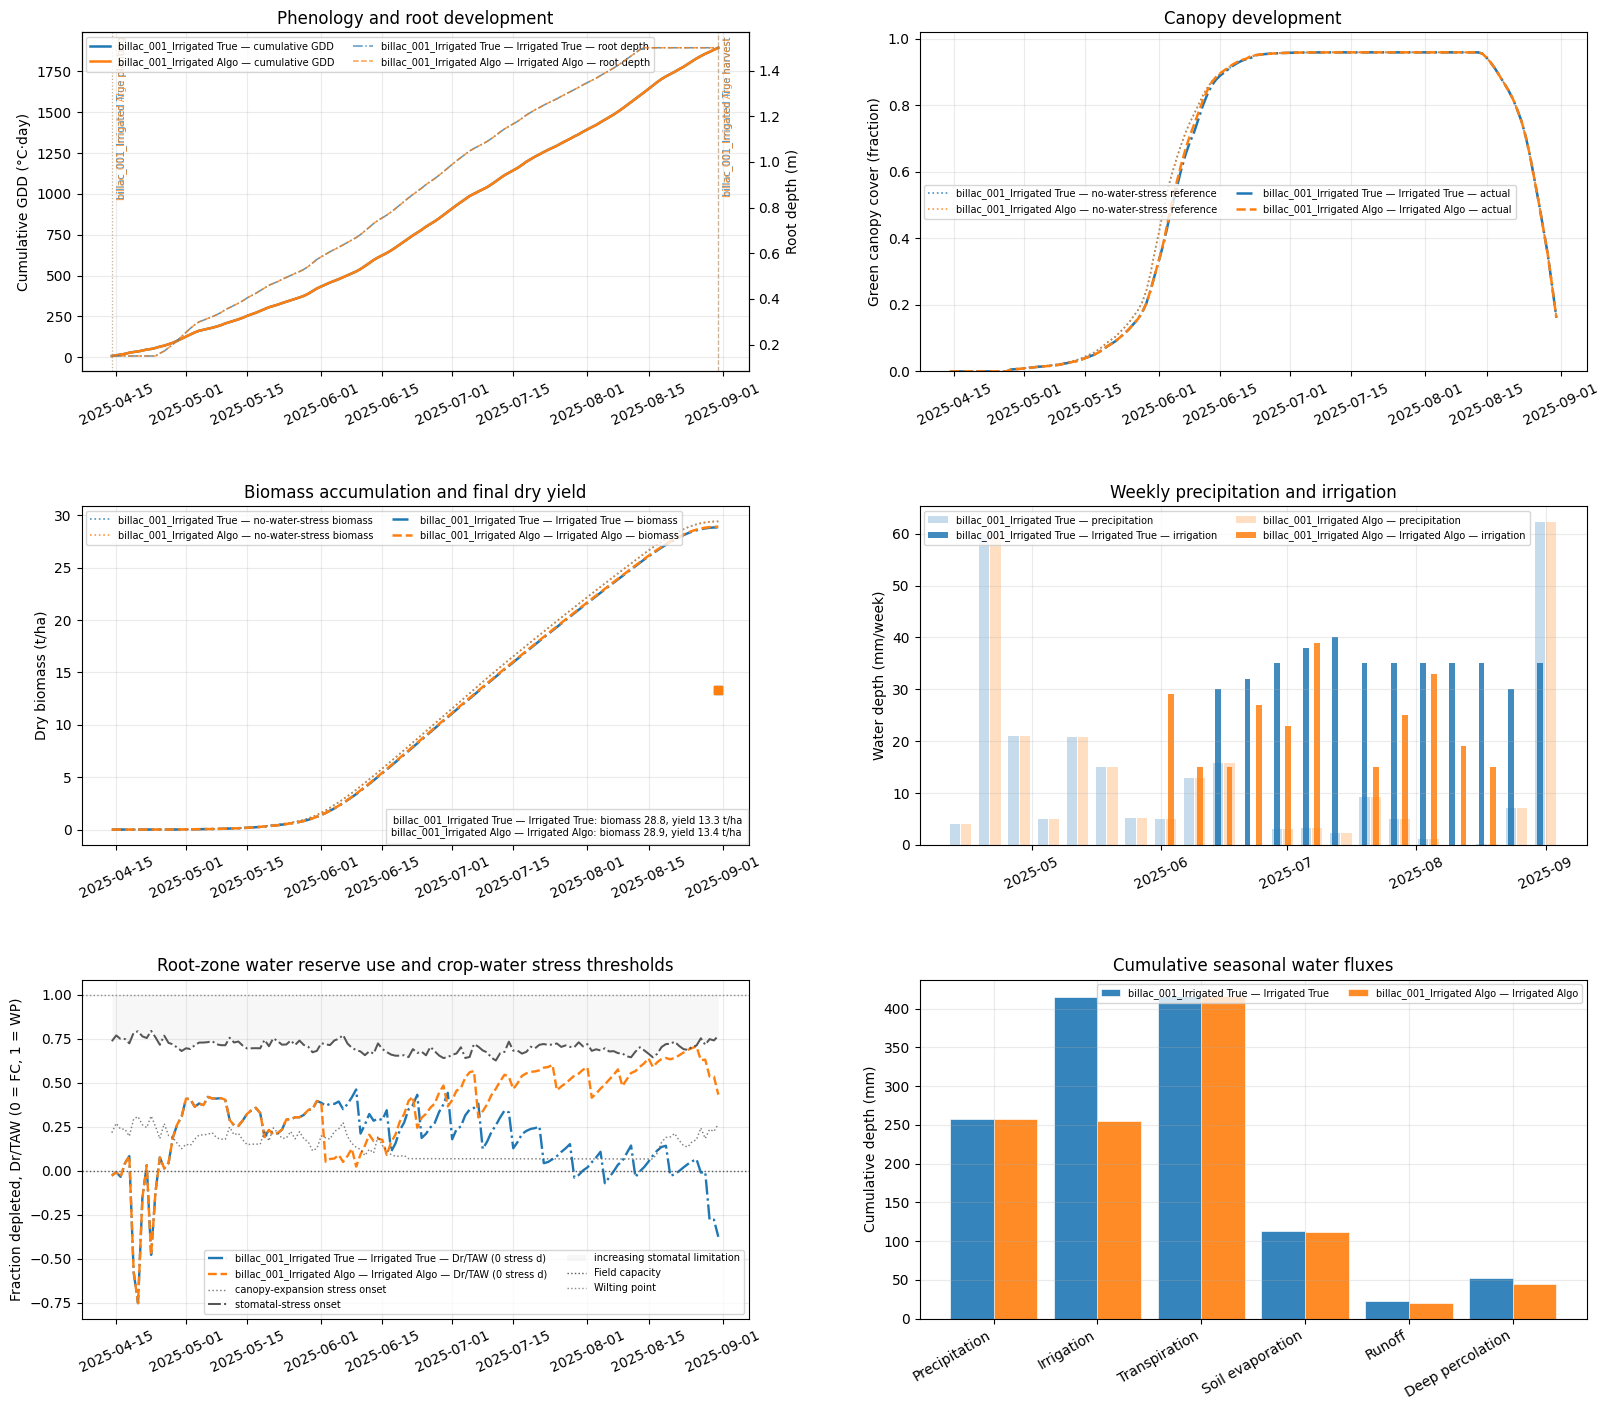

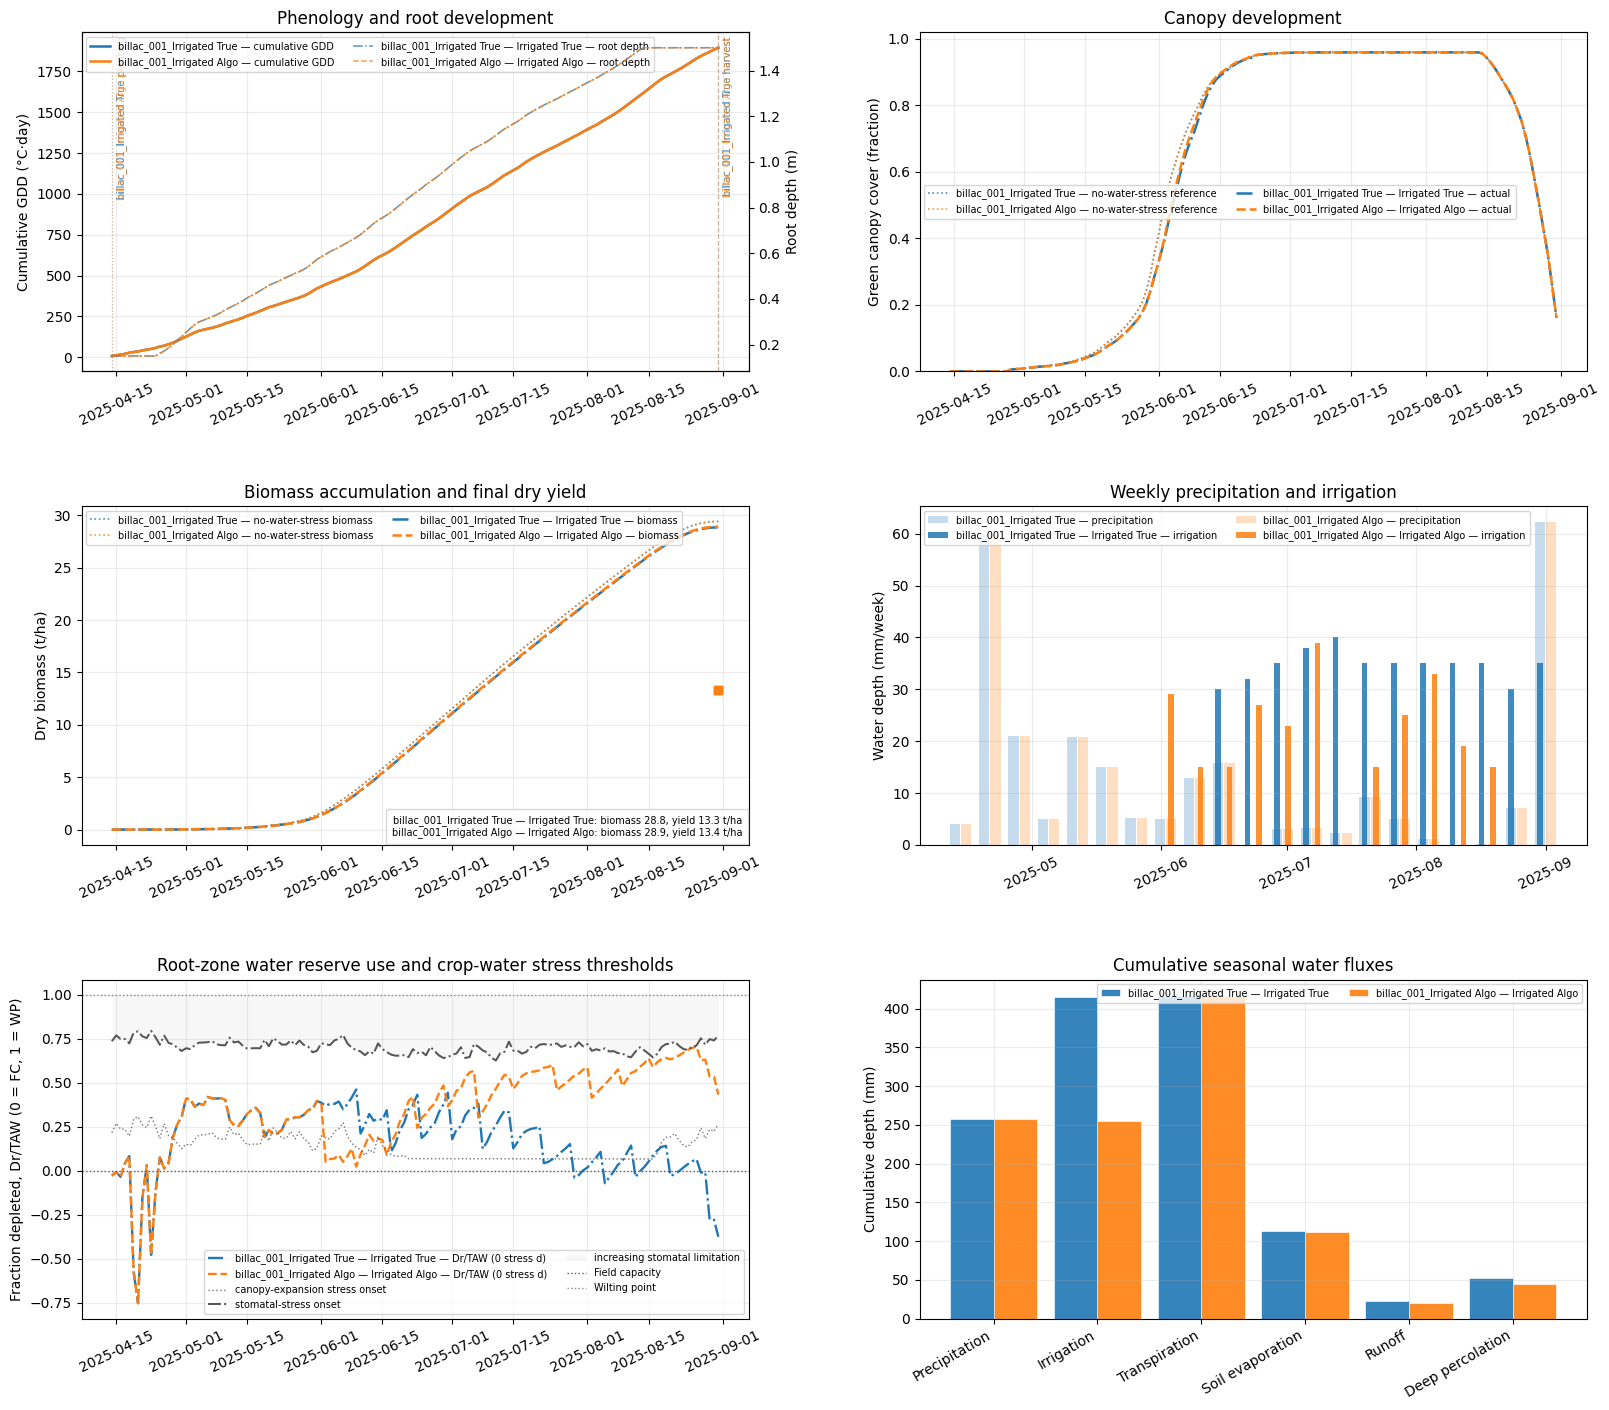

In [5]:
from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)
parcel2 = load_parcel_config(PARCEL_CONFIG_IRR)
parcel3 = load_parcel_config(PARCEL_CONFIG_OPT)

soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)


parcels = [parcel, parcel2, parcel3, new_parcel]
names = ["Billac No Irr", "Billac True Irr", "Billac Optimal Irr", "Billac Algo Irr"]
scenario = ["Non Irrigated", "Irrigated True", "Irrigated Opt", "Irrigated Algo"]

parcels = [ parcel2, parcel3, new_parcel]
names = ["Billac True Irr", "Billac Optimal Irr", "Billac Algo Irr"]
scenario = ["Irrigated True", "Irrigated Opt", "Irrigated Algo"]

parcels = [parcel2, new_parcel]
names = ["Billac True Irr",  "Billac Algo Irr"]
scenario = ["Irrigated True", "Irrigated Algo"]

compare_irrigation_strategies(parcels=parcels, names=names, scenario=scenario, soil=soil, terrain=terrain,sim_start=SIMULATION_START)



---
## Block 0 — Data Ingestion

Run these cells **once** to download and cache the historical archive.
Skip if data is already on disk.

ERA5-Land is downloaded for all of France — not per region. One download
covers any parcel in metropolitan France.

In [4]:
from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)
parcel2 = load_parcel_config(PARCEL_CONFIG2)

print(f"Region: {cfg.name} (dept {cfg.code_departement})")
print(f"Parcel: {parcel.name} ({parcel.id})")
print(f"Crop:   {parcel.crop.get('type')} — planting {parcel.crop.get('planting_date')}")

Region: Dordogne (dept 24)
Parcel: Parcelle Billac - SEP des Pouyades (billac_001)
Crop:   grain_maize — planting 2026-04-14


---
## Block 1 — Static Layers (parcel-level)

Extract soil and terrain at the parcel location. Run once per parcel, cache.

In [5]:
from irrigator.static_layers.soil import get_soil_profile
from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation

soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)

soil2 = get_soil_profile(cfg, parcel2)
terrain2 = get_terrain_params(cfg, parcel2)
terrain2.era5_elevation_m = get_era5_elevation(cfg, parcel2)

print(f"Soil AWC:  {soil.total_awc_mm:.0f} mm (source: {soil.source})")
print(f"Elevation: {terrain.elevation_m:.0f} m (ERA5 cell: {terrain.era5_elevation_m:.0f} m)")
print(f"Slope:     {terrain.slope_deg:.1f}°")

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
2026-09-10 16:59:42,803 Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
2026-09-10 16:59:42,824 Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
2026-09-10 16:59:42,827 Opening 200 ERA5-Land files with dask
2026-09-10 16:59:51,103 Parcel guide_001: using EU-SoilHydroGrids — AWC=249 mm, FC=[0.360, 0.350, 0.340, 0.340, 0.331, 0.317]
2026-09-10 16:59:51,117 Parcel guide_001 terrain: elev=141 m, slope=3.3°, aspect=282°
2026-09-10 16:59:51,120 Opening 200 ERA5-Land files with dask


Soil AWC:  235 mm (source: eu_soilhydrogrids)
Elevation: 140 m (ERA5 cell: 145 m)
Slope:     3.1°


In [4]:
from irrigator.water_balance.soil_water_content import (
    build_initial_soil_water_profile_from_era5_land,
)

initial_soil_water_parcel = build_initial_soil_water_profile_from_era5_land(
    soil_profile=soil,
    parcel_profile=parcel,
    date=SIMULATION_START,
    processed_dir=PROCESSED_DIR,
    raw_dir=RAW_DIR,
    static_dir=STATIC_DIR,
)
initial_soil_water_parcel2 = build_initial_soil_water_profile_from_era5_land(
    soil_profile=soil2,
    parcel_profile=parcel2,
    date=SIMULATION_START,
    processed_dir=PROCESSED_DIR,
    raw_dir=RAW_DIR,
    static_dir=STATIC_DIR,
)

---
## Block 2 — Atmospheric Forcing

Process ERA5-Land hourly → daily (once for all of France), then extract at parcel.

The daily cache is grid-agnostic: any parcel in France can extract its
forcing from the same file via `extract_parcel_forcing()`.

In [ ]:
from irrigator.atmospheric.era5_processor import load_daily, process_era5_to_daily, save_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing


# # After that: just load cached
era5_daily = load_daily(processed_dir=PROCESSED_DIR, year=SIMULATION_START.year)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)
forcing2 = extract_parcel_forcing(era5_daily, parcel2, terrain2)

print(f"ERA5 grid: {dict(era5_daily.sizes)}")
print(f"Forcing: {forcing.n_days} days")
print(f"T range: [{forcing.t_min.min():.1f}, {forcing.t_max.max():.1f}] °C")
print(f"Total precip: {forcing.precip_mm.sum():.0f} mm")

11:38:58 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 223 days from ERA5-Land at grid cell (0, 45)
11:38:58 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:38:58 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 223 days, T=[-5.1, 39.8]°C, total precip=522 mm, mean Rs=17.1 MJ/m²/day
11:38:58 [irrigator.atmospheric.forcing] INFO: Parcel guide_001: extracted 223 days from ERA5-Land at grid cell (0, 45)
11:38:58 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=3 m, ΔT=-0.02°C
11:38:58 [irrigator.atmospheric.forcing] INFO: Parcel guide_001 forcing: 223 days, T=[-5.2, 39.7]°C, total precip=522 mm, mean Rs=17.0 MJ/m²/day


ERA5 grid: {'valid_time': 223, 'latitude': 106, 'longitude': 161}
Forcing: 223 days
T range: [-5.1, 39.8] °C
Total precip: 522 mm


---
## Blocks 3+4 — Historical Simulation up to TODAY

Coupled crop growth + water balance from `SIMULATION_START` to `TODAY`.
The final state is the starting point for the forecast.

In [6]:
from irrigator.water_balance.aquacrop_adapter import run_aquacrop
import pandas as pd

historical_forcing = forcing.slice(SIMULATION_START, TODAY - timedelta(days=1))
historical_forcing2 = forcing2.slice(SIMULATION_START, TODAY - timedelta(days=1))

LAST_ERA5_DAY = pd.to_datetime(historical_forcing.dates[-1]).date()

hist_run = run_aquacrop(
    forcing=historical_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=LAST_ERA5_DAY,
    initial_soil_water_profile=initial_soil_water_parcel,
)


hist_run2 = run_aquacrop(
    forcing=historical_forcing2,
    parcel=parcel2,
    terrain=terrain2,
    soil_profile=soil2,
    sim_start=SIMULATION_START,
    sim_end=LAST_ERA5_DAY,
    initial_soil_water_profile=initial_soil_water_parcel2,
)

# Daily stress metrics (Ks equivalent, canopy cover, biomass, etc.)
stress = hist_run.daily_stress
# Drop rows past your actual data
valid = stress[stress["dap"] > 0].iloc[:-1]  # drop AquaCrop's terminal zero-row
last = valid.iloc[-1]

print(f"GDD: {last.gdd_cum:.0f}")
print(f"Canopy: {last.canopy_cover:.2f}")
print(f"Ks: {last.ks:.3f}")


11:38:58 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


MaizeGDD


11:38:58 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-07-13 (194 days), GDD=1238, CC=0.96, biomass=1665 kg/ha
11:38:58 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.317-0.355, WP range 0.171-0.210, Ksat range 42-662 mm/day


MaizeGDD


11:38:59 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-07-13 (194 days), GDD=1305, CC=0.96, biomass=1849 kg/ha


GDD: 1238
Canopy: 0.96
Ks: 1.000


---
## Block 5a — Operational forecast with AquaCrop

With AquaCrop, forecasting means rerunning the full simulation from Jan 1
with different future forcings appended. This preserves the stress-growth
coupling — a crop that was stressed in June will have smaller canopy in
July, which reduces water demand.

- **AROME** (0-48h): one AquaCrop run with deterministic forecast appended
- **IFS ENS** (0-15d): 50 AquaCrop runs, one per ensemble member
- **Blended report**: AROME days 0-2 (high resolution), IFS ENS days 3+ (ensemble spread)

In [7]:
# --- Cell: Extract current state from historical AquaCrop run ---
# (put this right after Block 3-4)

from irrigator.water_balance.aquacrop_adapter import (
    aquacrop_to_current_state,
    build_blended_stress_report,
    run_ensemble_aquacrop,
)

current_state = aquacrop_to_current_state(hist_run, soil, LAST_ERA5_DAY)

print(f"Current state at {LAST_ERA5_DAY}:")
print(f"  Depletion:  {current_state.depletion:.0f} mm")
print(f"  TAW:        {current_state.taw:.0f} mm")
print(f"  RAW:        {current_state.raw:.0f} mm")
print(f"  Ks:         {current_state.stress_coeff:.3f}")
print(f"  Root depth: {current_state.z_root:.2f} m")
print(f"  GDD:        {current_state.gdd:.0f}")
print(f"  Stage:      {current_state.crop_stage}")


Current state at 2026-07-13:
  Depletion:  89 mm
  TAW:        145 mm
  RAW:        63 mm
  Ks:         1.000
  Root depth: 1.24 m
  GDD:        1238
  Stage:      midseason


In [8]:
# --- Cell: Build historical forcing for forecast branching ---

from irrigator.atmospheric.forcing import extract_parcel_forcing
from irrigator.forecasts.arome_processing import load_arome_daily_cache
from datetime import timedelta
import numpy as np

# ERA5-Land historical
#era5_last = pd.Timestamp(era5_daily.valid_time.values[-1]).date()
era5_forcing = forcing.slice(SIMULATION_START, LAST_ERA5_DAY)

# AROME gap fill (era5_last → yesterday)
gap_start = LAST_ERA5_DAY + timedelta(days=1)
gap_end = TODAY - timedelta(days=1)

if gap_start <= gap_end:
    arome_gap = load_arome_daily_cache(gap_start, gap_end, mode="static")
    gap_forcing = extract_parcel_forcing(arome_gap, parcel, terrain)
    historical_forcing = era5_forcing.concat(gap_forcing)
    print(f"Gap filled: {gap_forcing.n_days} days ({gap_start} → {gap_end})")
else:
    historical_forcing = era5_forcing
    print("No gap to fill")

print(f"Historical forcing: {historical_forcing.n_days} days")



No gap to fill
Historical forcing: 194 days


In [9]:
# --- Cell: AROME 48h deterministic forecast ---

arome_today = load_arome_daily_cache(TODAY , TODAY + timedelta(days=1), mode="forecast")
arome_forcing_48h = extract_parcel_forcing(arome_today, parcel, terrain)
# Fix date alignment if needed
arome_forcing_48h.dates = arome_forcing_48h.dates #- np.timedelta64(1, "D")

print(f"AROME forecast: {arome_forcing_48h.n_days} days")
print(f"  T range: [{arome_forcing_48h.t_min.min():.1f}, {arome_forcing_48h.t_max.max():.1f}] °C")

# Run full AquaCrop: historical + AROME 48h
arome_full_forcing = historical_forcing.concat(arome_forcing_48h)


arome_run = run_aquacrop(
    forcing=arome_full_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=pd.Timestamp(arome_full_forcing.dates[-1]).date(),
    initial_soil_water_profile=initial_soil_water_parcel
)

# Quick check: AROME Ks for the forecast days
arome_stress = arome_run.daily_stress
print(f"AROME last 3 days Ks: {arome_stress.ks.iloc[-4:-1].values}")


11:39:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 4 days from ERA5-Land at grid cell (0, 45)
11:39:00 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:39:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 4 days, T=[19.5, 35.9]°C, total precip=0 mm, mean Rs=26.4 MJ/m²/day
11:39:00 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


AROME forecast: 4 days
  T range: [19.5, 35.9] °C
MaizeGDD


11:39:00 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-07-16 (197 days), GDD=1299, CC=0.96, biomass=1762 kg/ha


AROME last 3 days Ks: [1.         1.         0.88665925]


In [10]:
# --- Cell: IFS ENS ensemble ---

from irrigator.ingestion.ifs_ens_client import load_ifs_daily

ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR, run_date=TODAY)

# Extract per-member forcing at parcel level
member_forcings = {}
for m in ifs_daily.number.values:
    member_ds = ifs_daily.sel(number=m)
    forcing_m = extract_parcel_forcing(member_ds, parcel, terrain)
    # Filter to remove arome overlap + limit due to shift utc + 1
    member_forcings[int(m)] = forcing_m.slice(start=TODAY + timedelta(2), end=TODAY + timedelta(14)) # hsould be 14

print(
    f"IFS ENS: {len(member_forcings)} members, {member_forcings[next(iter(member_forcings))].n_days} days"
)

# Run AquaCrop for each member (full simulation: Jan 1 → forecast end)
# Each member gets historical + its own forecast forcing
ensemble_stats = run_ensemble_aquacrop(
    historical_forcing=historical_forcing,
    arome_forcing=arome_forcing_48h,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    today=TODAY - timedelta(days=1),
    initial_soil_water_profile=initial_soil_water_parcel,
)

print(f"Ensemble stats: {len(ensemble_stats)} days")
for s in ensemble_stats[:3]:
    print(
        f"  Day {s.day_offset}: Ks={s.ks_mean:.3f} (p25={s.ks_p25:.3f}, p75={s.ks_p75:.3f}), "
        f"stress={s.n_members_stressed}/{s.n_members_total}"
    )

# pd.Timestamp(arome_full_forcing.dates[-2]).date()

11:39:01 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
11:39:01 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:39:01 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[16.0, 34.9]°C, total precip=27 mm, mean Rs=22.9 MJ/m²/day
11:39:01 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
11:39:01 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:39:01 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[16.9, 36.1]°C, total precip=8 mm, mean Rs=24.3 MJ/m²/day
11:39:01 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
11:39:01 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:39:01 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[18.5, 36.0]°C, 

IFS ENS: 50 members, 13 days
MaizeGDD


11:39:16 [irrigator.water_balance.aquacrop_adapter] INFO: Ensemble complete: 13 days, 50 members, stress_days=13


Ensemble stats: 13 days
  Day 0: Ks=0.810 (p25=0.810, p75=0.810), stress=50/50
  Day 1: Ks=0.889 (p25=0.849, p75=0.922), stress=34/50
  Day 2: Ks=0.815 (p25=0.772, p75=0.842), stress=44/50


In [11]:
# --- Cell: Blend AROME + IFS ENS into stress report ---

stress_report = build_blended_stress_report(
    arome_run=arome_run,
    ensemble_stats=ensemble_stats,
    today=TODAY,
    arome_days=2,
)

print(
    f"Blended report: {len(stress_report.daily_stats)} days "
    f"({stress_report.arome_days} AROME + {stress_report.ens_days} IFS ENS)"
)
for d in stress_report.daily_stats[:5]:
    print(
        f"  {d.date.date() if hasattr(d.date, 'date') else d.date}: "
        f"[{d.source}] Ks={d.ks_median:.3f}, stress_prob={d.stress_probability:.0%}"
    )


Blended report: 15 days (2 AROME + 13 IFS ENS)
  2026-07-14: [arome] Ks=0.887, stress_prob=100%
  2026-07-15: [arome] Ks=0.788, stress_prob=100%
  2026-07-16: [ifs_ens] Ks=0.810, stress_prob=100%
  2026-07-17: [ifs_ens] Ks=0.872, stress_prob=68%
  2026-07-18: [ifs_ens] Ks=0.794, stress_prob=88%


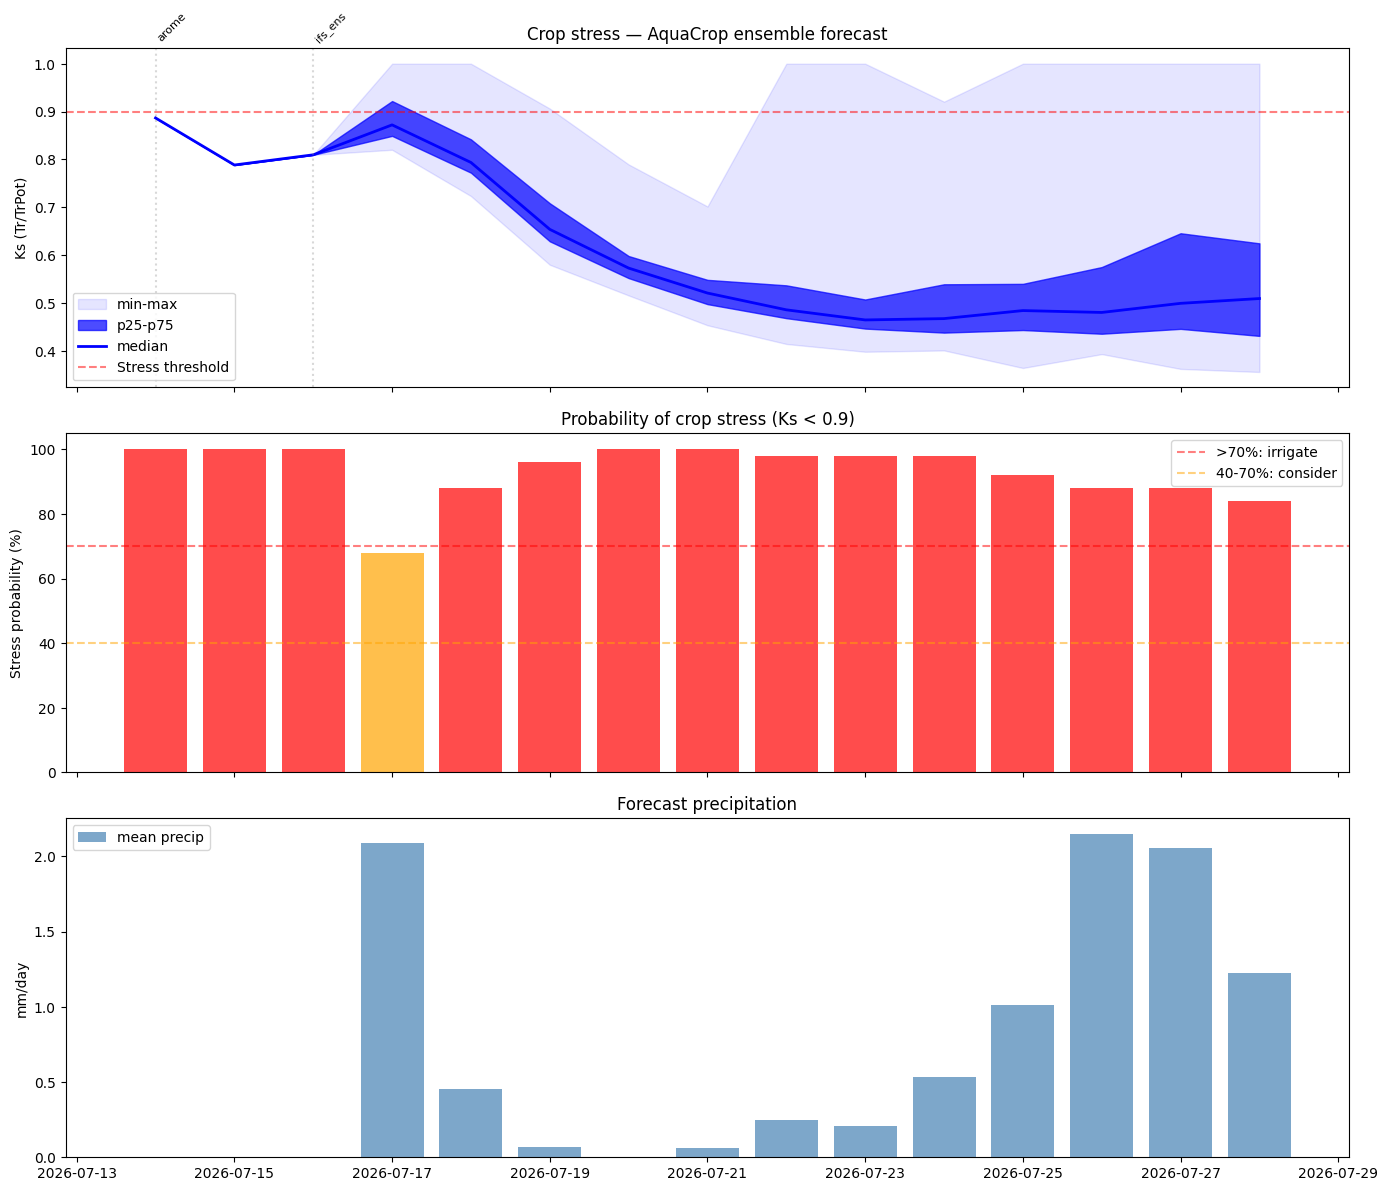

In [12]:
# --- Cell: Plot ensemble forecast (same as before, works unchanged) ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

dates = [d.date for d in stress_report.daily_stats]
sources = [d.source for d in stress_report.daily_stats]

# Ks with ensemble spread
ax = axes[0]
ks_med = [d.ks_median for d in stress_report.daily_stats]
ks_p25 = [d.ks_p25 for d in stress_report.daily_stats]
ks_p75 = [d.ks_p75 for d in stress_report.daily_stats]
ks_min = [d.ks_min for d in stress_report.daily_stats]
ks_max = [d.ks_max for d in stress_report.daily_stats]

ax.fill_between(dates, ks_min, ks_max, alpha=0.1, color="blue", label="min-max")
ax.fill_between(dates, ks_p25, ks_p75, alpha=0.7, color="blue", label="p25-p75")
ax.plot(dates, ks_med, "b-", lw=2, label="median")
ax.axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")

for i, (d, src) in enumerate(zip(dates, sources)):
    if i == 0 or sources[i] != sources[i - 1]:
        ax.axvline(d, color="gray", ls=":", alpha=0.3)
        ax.text(d, 1.02, src, fontsize=8, rotation=45, transform=ax.get_xaxis_transform())

ax.set_ylabel("Ks (Tr/TrPot)")
ax.set_title("Crop stress — AquaCrop ensemble forecast")
ax.legend(loc="lower left")

# Stress probability
ax = axes[1]
stress_prob = [d.stress_probability for d in stress_report.daily_stats]
colors = ["red" if p > 0.7 else "orange" if p > 0.4 else "green" for p in stress_prob]
ax.bar(dates, [p * 100 for p in stress_prob], color=colors, alpha=0.7)
ax.axhline(70, color="red", ls="--", alpha=0.5, label=">70%: irrigate")
ax.axhline(40, color="orange", ls="--", alpha=0.5, label="40-70%: consider")
ax.set_ylabel("Stress probability (%)")
ax.set_title("Probability of crop stress (Ks < 0.9)")
ax.legend()

# Precipitation
ax = axes[2]
precip_mean = [d.precip_mean for d in stress_report.daily_stats]
ax.bar(dates, precip_mean, color="steelblue", alpha=0.7, label="mean precip")
ax.set_ylabel("mm/day")
ax.set_title("Forecast precipitation")
ax.legend()

plt.tight_layout()
plt.show()


---
## Block 5b — Seasonal Outlook (SEAS5, optional)

PCA analog matching → daily disaggregation → ensemble water balance.
Set `RUN_SEAS5 = True` at the top to enable.

In [12]:
seasonal_scenarios = None
member_forcings_to_harvest = None
import pandas as pd
RUN_SEAS5 = False
PLOT_SEAS5_PCA = True


if RUN_SEAS5:
    import xarray as xr
    from irrigator.ingestion.cds_client import (
        fetch_seas5,
        fetch_seas5_hindcasts,
        open_seas5,
    )
    from irrigator.forecasts.seas5_processor import (
        prepare_seas5_monthly,
        open_era5_daily_archive,
        build_era5_monthly_climatology,
        build_seas5_hindcast_climatology,
        correct_seas5_monthly,
    )
    from irrigator.forecasts.disaggregation import (
        MATCHING_VARIABLES,
        generate_seasonal_scenarios,
        project_seas5_members_to_pca,
        get_historical_monthly_fields,
        build_metropolitan_france_mask,
        build_intersection_mask,
        _coarsen_to_seas5,
        build_historical_pca,
    )
    from irrigator.forecasts.pca_framework import fit_monthly_regional_pca
    from irrigator.forecasts.pipeline import extend_ifs_members_with_seasonal

    init_year = TODAY.year
    init_month = TODAY.month
    analog_start_year = 1993
    analog_end_year = TODAY.year - 1

    

    # ------------------------------------------------------------------
    # 1) SEAS5 forecast + one-time hindcast climatology
    # ------------------------------------------------------------------
    # The new seasonal path uses tmin/tmean/tmax/dewpoint/wind/radiation/precip.
    # Set REFRESH_SEAS5=True once if the existing cached file contains only the
    # older temperature + precipitation request.
    fetch_seas5(
        year=init_year,
        month=init_month,
        raw_dir=RAW_DIR,
        overwrite=REFRESH_SEAS5,
    )
    print("Fetched")
    if FETCH_SEAS5_HINDCASTS:
        fetch_seas5_hindcasts(
            init_month=init_month,
            raw_dir=RAW_DIR,
            overwrite=REFRESH_SEAS5,
        )

    seas5_raw = open_seas5(raw_dir=RAW_DIR, year=init_year, month=init_month)
    
    # seas5_monthly = prepare_seas5_monthly( # TO FOCUS ON
    #     seas5_raw,
    #     init_year=init_year,
    #     init_month=init_month,
    # )
    seas5_monthly = seas5_raw

    # Historical ERA5-Land archive used for both climatology and analogs.
    # These annual daily files must already exist in data/processed/atmospheric.
    era5_monthly = _coarsen_to_seas5(get_historical_monthly_fields())
    era5_clim = build_era5_monthly_climatology(
        start_year=1993,
        end_year=2016,
        era5_monthly=era5_monthly,
    )

    seasonal_dir = PROCESSED_DIR / "seasonal"
    seasonal_dir.mkdir(parents=True, exist_ok=True)
    hindcast_clim_path = seasonal_dir / f"seas5_hindcast_clim_init_{init_month:02d}.nc"
    if hindcast_clim_path.exists() and not REFRESH_SEAS5:
        seas5_clim = xr.open_dataset(hindcast_clim_path)
    else:
        seas5_clim = build_seas5_hindcast_climatology(
            raw_dir=RAW_DIR,
            init_month=init_month,
            start_year=1993,
            end_year=2016,
        )
        seas5_clim.load().to_netcdf(hindcast_clim_path)

    seas5_corrected = correct_seas5_monthly(
        seas5_monthly,
        era5_climatology=era5_clim,
        init_month=init_month,
        seas5_climatology=seas5_clim,
    )

    # ------------------------------------------------------------------
    # 2) France-level PCA. Cache the monthly ERA5 fields: this avoids
    #    re-reading/aggregating decades of daily ERA5 at every daily run.
    # ------------------------------------------------------------------

    # france_pca = build_historical_pca(
    #     overwrite_era5=False,
    #     variables=MATCHING_VARIABLES,
    #     n_components=10,
    # )
    france_pca = build_historical_pca(
        overwrite_era5=False,
        variables=MATCHING_VARIABLES,
        target_grid=seas5_corrected,
        n_components=10,
    )
    print("PCA")

    # IFS is retained wherever it overlaps. The first seasonal month is
    # reconstructed as a full month before being sliced at the transition.
    seasonal_transition = TODAY + timedelta(days=15)
    seasonal_scenarios = generate_seasonal_scenarios(
        cfg=cfg,
        seas5_corrected=seas5_corrected,
        init_year=init_year,
        init_month=init_month,
        n_leads=3,
        variables=MATCHING_VARIABLES,
        method="sample",
        analog_top_k=1,
        random_seed=42,
        start_date=seasonal_transition,
        pca_model=france_pca,
        # Optional safeguard if you want to reject extreme precipitation
        # amplitude corrections, e.g. (0.25, 4.0). None preserves the target
        # monthly precipitation exactly for every selected analog.
        precip_scale_bounds=None,
    )

    expected_harvest = pd.Timestamp(parcel.crop["expected_harvest"]).date()
    member_forcings_to_harvest = extend_ifs_members_with_seasonal(
        member_forcings,
        seasonal_scenarios,
        parcel=parcel,
        terrain=terrain,
        known_prefix_forcing=historical_forcing.concat(arome_forcing_48h),
        end_date=expected_harvest,
    )

    print(f"SEAS5-conditioned scenarios: {len(seasonal_scenarios)}")
    print(f"PCA variables: {MATCHING_VARIABLES}")
    print(
        "Common member horizon:",
        min(pd.Timestamp(f.dates[-1]).date() for f in member_forcings_to_harvest.values()),
    )
    print("First member analogs:")
    for a in seasonal_scenarios[0].analogs:
        print(
            f"  target {a.target_year}-{a.target_month:02d} -> "
            f"ERA5 {a.analog_year}-{a.analog_month:02d} "
            f"(rank {a.rank}, d={a.distance:.2f})"
        )

    # # ------------------------------------------------------------------
    # # 4) PCA diagnostic: historical ERA5 months vs SEAS5 ensemble
    # # ------------------------------------------------------------------
    # if PLOT_SEAS5_PCA and seasonal_scenarios and france_pca.pc_scores.sizes["component"] >= 2:
    #     first_target = seasonal_scenarios[0].analogs[0]
    #     pca_plot_lead = (first_target.target_year - init_year) * 12 + (first_target.target_month - init_month) + 1
    #     seas5_pc = project_seas5_members_to_pca(
    #         seas5_corrected,
    #         france_pca,
    #         pca_variables,
    #         init_year=init_year,
    #         init_month=init_month,
    #         lead=pca_plot_lead,
    #     )
    #     hist_pc = france_pca.pc_scores.sel(
    #         time=france_pca.pc_scores.time.dt.month == first_target.target_month
    #     )

    #     fig, ax = plt.subplots(figsize=(9, 6))
    #     ax.scatter(
    #         hist_pc.sel(component="PC1"),
    #         hist_pc.sel(component="PC2"),
    #         alpha=0.65,
    #         label=f"ERA5-Land historical {first_target.target_month:02d}",
    #     )
    #     for ts, x, y in zip(
    #         pd.to_datetime(hist_pc.time.values),
    #         hist_pc.sel(component="PC1").values,
    #         hist_pc.sel(component="PC2").values,
    #     ):
    #         ax.annotate(str(ts.year), (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)
    #     ax.scatter(
    #         seas5_pc["PC1"],
    #         seas5_pc["PC2"],
    #         marker="x",
    #         s=45,
    #         label=f"Corrected SEAS5 {first_target.target_year}-{first_target.target_month:02d}",
    #     )
    #     ax.axhline(0, linewidth=0.6, alpha=0.4)
    #     ax.axvline(0, linewidth=0.6, alpha=0.4)
    #     ax.set_xlabel("PC1")
    #     ax.set_ylabel("PC2")
    #     ax.set_title("France-level PCA: SEAS5 ensemble vs historical ERA5-Land months")
    #     ax.legend()
    #     fig.tight_layout()
    #     plt.show()
else:
    print("SEAS5 seasonal scenarios skipped (set RUN_SEAS5=True to enable)")
    member_forcings_to_harvest = member_forcings



SEAS5 seasonal scenarios skipped (set RUN_SEAS5=True to enable)


---
## Block 6 — Yield-constrained irrigation optimizer

This replaces the combinatorial stress-minimization search. Water stress is used only to
locate candidate intervention windows; the objective is **minimum irrigation subject to a
dry-yield constraint**. The optimizer first tests no future irrigation, adds only the events
needed to recover yield, then reduces each dose with a one-dimensional search.

For an operational run, each IFS member must be extended through harvest with the SEAS5
conditioned daily scenarios from Block 5b. A plan from yesterday can be passed through
`previous_plan`; dates inside the commitment horizon are preserved while their dose is updated.


In [ ]:



RUN_YIELD_OPTIMIZER = True
require_harvest_horizon = False

if RUN_YIELD_OPTIMIZER:
    if member_forcings_to_harvest is None:
        raise RuntimeError(
            "The yield optimizer needs weather through harvest. Set RUN_SEAS5=True "
            "and run Block 5b first."
        )

    from irrigator.water_balance.yield_optimizer import (
        YieldConstraint,
        optimize_operational_irrigation,
    )

    # Example: yesterday's plan. Keep [] on the first run. On subsequent days,
    # store yield_plan.recommended_events and pass that list here.
    # If planned to use previous_plan
    previous_plan = parcel.irrigation_log
    previous_plan = []

    yield_plan = optimize_operational_irrigation(
        historical_forcing=historical_forcing,
        arome_forcing=arome_forcing_48h,
        future_member_forcings=member_forcings_to_harvest,
        parcel=parcel,
        terrain=terrain,
        soil_profile=soil,
        today=TODAY,
        sim_start=SIMULATION_START,
        previous_plan=previous_plan,
        commitment_days=2,
        constraint=YieldConstraint(
            max_relative_loss=0.01,  # accept <=1% dry-yield loss
            # min_member_probability=0.80,  # in at least 80% of weather members
            min_member_probability=0.85,  # in at least 99% of weather members
            absolute_tolerance_t_ha=0.01,
        ),
        stress_trigger_ks=0.98,  # date-finding signal only, NOT objective
        trigger_quantile=0.25,  # act before the earlier stressed members
        irrigation_lead_days=1,
        dose_resolution_mm=2.0,
        max_events=8,
        n_workers=10,
        require_harvest_horizon=require_harvest_horizon,
        initial_soil_water_profile=initial_soil_water_parcel,
    )

    print(f"Feasible: {yield_plan.feasible}")
    print(f"Reason:   {yield_plan.reason}")
    print(f"Yield-constraint success probability: {yield_plan.success_probability:.0%}")
    print(f"Recommended water: {yield_plan.recommended_total_mm:.1f} mm")
    display(yield_plan.to_dataframe())

    ratios = yield_plan.optimized_evaluation.yield_ratios(yield_plan.reference_yields_t_ha)
    print(
        "Yield ratio vs attainable reference: "
        f"median={np.median(list(ratios.values())):.3f}, "
        f"min={np.min(list(ratios.values())):.3f}"
    )
else:
    print("Yield optimizer skipped (set RUN_YIELD_OPTIMIZER=True)")


11:40:39 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


MaizeGDD
Feasible: True
Reason:   Yield constraint reached with event-triggered schedule.
Yield-constraint success probability: 92%
Recommended water: 56.0 mm


,date,day_offset,amount_mm,committed
0,2026-07-15,1,41.0,False
1,2026-07-22,8,15.0,False


Yield ratio vs attainable reference: median=0.997, min=0.981


In [16]:
from irrigator.config import load_parcel_config, save_parcel_config
config_path = f"configs/parcels/billac_{TODAY.year}_TEST.yaml"
save_parcel_config(parcel.add_irrigation_event(yield_plan.to_irrigation_log()), config_path)

11:41:42 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 4 days from ERA5-Land at grid cell (0, 45)
11:41:42 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:41:42 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 4 days, T=[19.5, 35.9]°C, total precip=0 mm, mean Rs=26.4 MJ/m²/day
11:41:42 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


AROME forecast: 4 days
  T range: [19.5, 35.9] °C
MaizeGDD


11:41:43 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-07-16 (197 days), GDD=1299, CC=0.96, biomass=1766 kg/ha
11:41:43 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
11:41:43 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:41:43 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[16.0, 34.9]°C, total precip=27 mm, mean Rs=22.9 MJ/m²/day
11:41:43 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
11:41:43 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
11:41:43 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[16.9, 36.1]°C, total precip=8 mm, mean Rs=24.3 MJ/m²/day
11:41:43 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
11:41:43 [irrigator.atmospheric.forcing

IFS ENS: 50 members, 13 days
MaizeGDD


11:41:57 [irrigator.water_balance.aquacrop_adapter] INFO: Ensemble complete: 13 days, 50 members, stress_days=0


Ensemble stats: 13 days
  Day 0: Ks=1.000 (p25=1.000, p75=1.000), stress=0/50
  Day 1: Ks=1.000 (p25=1.000, p75=1.000), stress=0/50
  Day 2: Ks=1.000 (p25=1.000, p75=1.000), stress=0/50


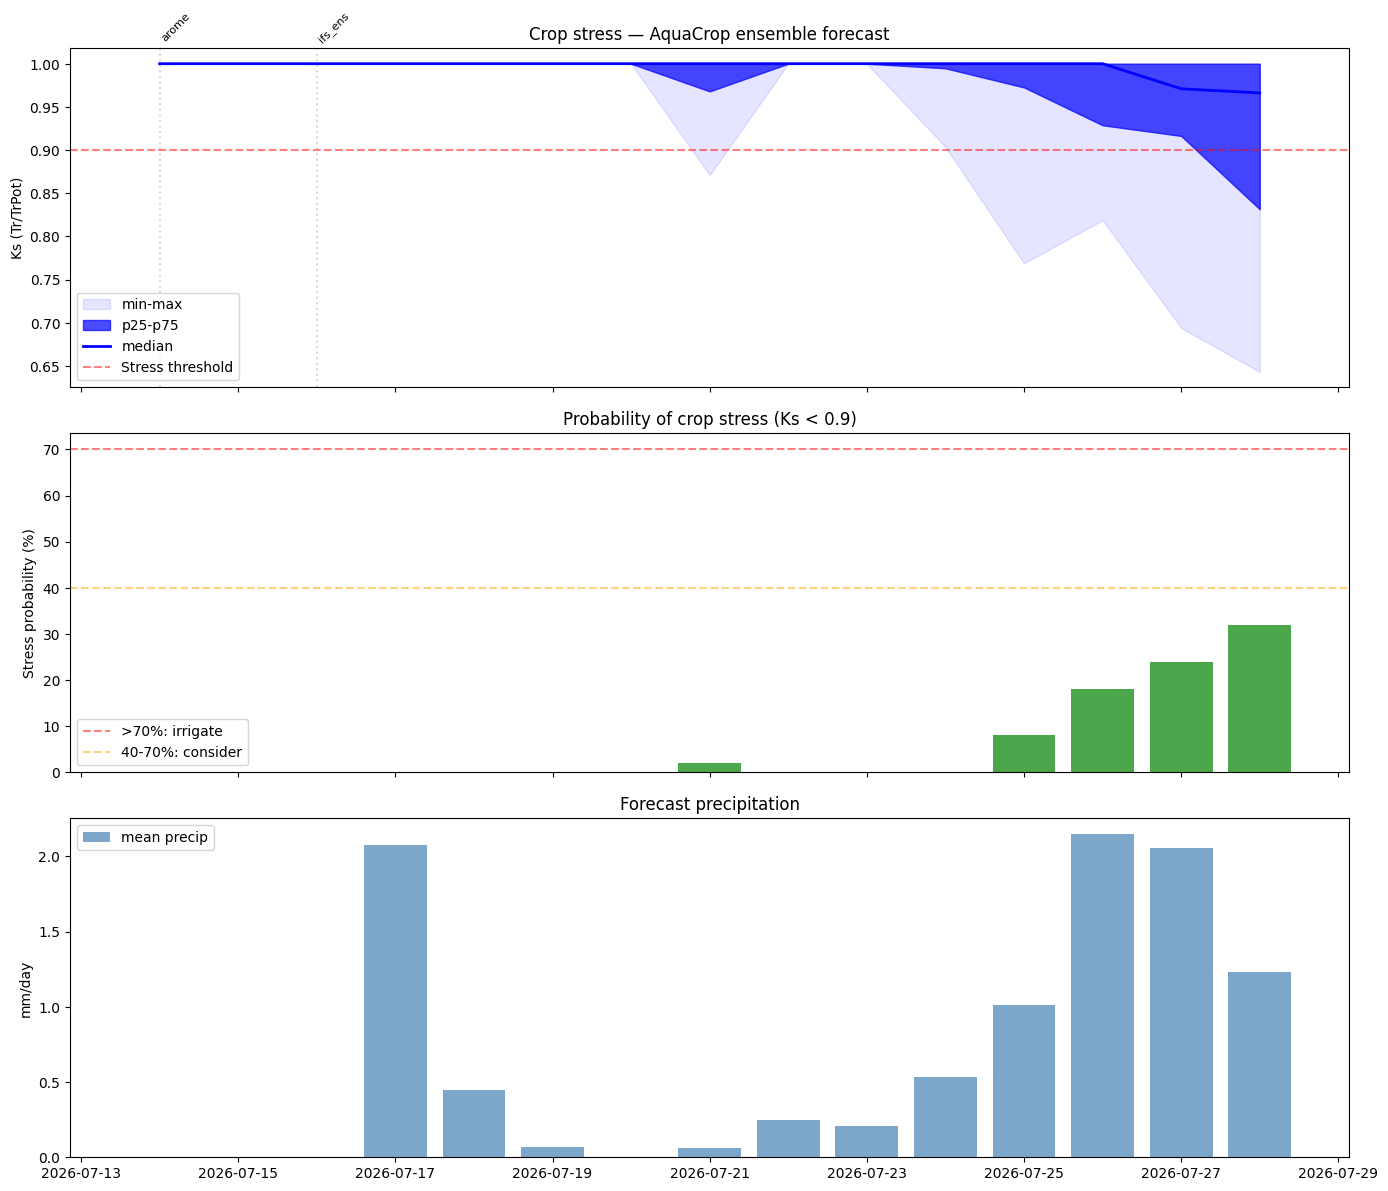

In [17]:
parcel_with_plan = parcel.add_irrigation_event(yield_plan.to_irrigation_log())

def run_forecast_pipeline_with_plan(parcel_with_plan, terrain, soil, initial_soil_water_parcel, historical_forcing):
    arome_today = load_arome_daily_cache(TODAY, TODAY + timedelta(days=1), mode="forecast")
    arome_forcing_48h = extract_parcel_forcing(arome_today, parcel_with_plan, terrain)
    # Fix date alignment if needed
    arome_forcing_48h.dates = arome_forcing_48h.dates  # - np.timedelta64(1, "D")

    print(f"AROME forecast: {arome_forcing_48h.n_days} days")
    print(f"  T range: [{arome_forcing_48h.t_min.min():.1f}, {arome_forcing_48h.t_max.max():.1f}] °C")

    # Run full AquaCrop: historical + AROME 48h
    arome_full_forcing = historical_forcing.concat(arome_forcing_48h)


    arome_run_with_plan = run_aquacrop(
        forcing=arome_full_forcing,
        parcel=parcel_with_plan,
        terrain=terrain,
        soil_profile=soil,
        sim_start=SIMULATION_START,
        sim_end=pd.Timestamp(arome_full_forcing.dates[-1]).date(),
        initial_soil_water_profile=initial_soil_water_parcel,
    )

    # Quick check: AROME Ks for the forecast days
    arome_stress = arome_run_with_plan.daily_stress


    from irrigator.ingestion.ifs_ens_client import load_ifs_daily

    ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR, run_date=TODAY)

    # Extract per-member forcing at parcel level
    member_forcings = {}
    for m in ifs_daily.number.values:
        member_ds = ifs_daily.sel(number=m)
        forcing_m = extract_parcel_forcing(member_ds, parcel_with_plan, terrain)
        # Filter to remove arome overlap + limit due to shift utc + 1
        member_forcings[int(m)] = forcing_m.slice(
            start=TODAY + timedelta(2), end=TODAY + timedelta(14)
        )  # hsould be 14

    print(
        f"IFS ENS: {len(member_forcings)} members, {member_forcings[next(iter(member_forcings))].n_days} days"
    )

    # Run AquaCrop for each member (full simulation: Jan 1 → forecast end)
    # Each member gets historical + its own forecast forcing
    ensemble_stats_with_plan = run_ensemble_aquacrop(
        historical_forcing=historical_forcing,
        arome_forcing=arome_forcing_48h,
        member_forcings=member_forcings,
        parcel=parcel_with_plan,
        terrain=terrain,
        soil_profile=soil,
        sim_start=SIMULATION_START,
        today=TODAY - timedelta(days=1),
        initial_soil_water_profile=initial_soil_water_parcel,
    )

    print(f"Ensemble stats: {len(ensemble_stats_with_plan)} days")
    for s in ensemble_stats_with_plan[:3]:
        print(
            f"  Day {s.day_offset}: Ks={s.ks_mean:.3f} (p25={s.ks_p25:.3f}, p75={s.ks_p75:.3f}), "
            f"stress={s.n_members_stressed}/{s.n_members_total}"
        )


    # --- Cell: Blend AROME + IFS ENS into stress report ---

    stress_report_with_plan = build_blended_stress_report(
        arome_run=arome_run_with_plan,
        ensemble_stats=ensemble_stats_with_plan,
        today=TODAY,
        arome_days=2,
    )

    return stress_report_with_plan


stress_report_with_plan = run_forecast_pipeline_with_plan(
    parcel_with_plan, terrain, soil, initial_soil_water_parcel, historical_forcing
)


# --- Cell: Plot ensemble forecast (same as before, works unchanged) ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

dates = [d.date for d in stress_report_with_plan.daily_stats]
sources = [d.source for d in stress_report_with_plan.daily_stats]

# Ks with ensemble spread
ax = axes[0]
ks_med = [d.ks_median for d in stress_report_with_plan.daily_stats]
ks_p25 = [d.ks_p25 for d in stress_report_with_plan.daily_stats]
ks_p75 = [d.ks_p75 for d in stress_report_with_plan.daily_stats]
ks_min = [d.ks_min for d in stress_report_with_plan.daily_stats]
ks_max = [d.ks_max for d in stress_report_with_plan.daily_stats]

ax.fill_between(dates, ks_min, ks_max, alpha=0.1, color="blue", label="min-max")
ax.fill_between(dates, ks_p25, ks_p75, alpha=0.7, color="blue", label="p25-p75")
ax.plot(dates, ks_med, "b-", lw=2, label="median")
ax.axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")

for i, (d, src) in enumerate(zip(dates, sources)):
    if i == 0 or sources[i] != sources[i - 1]:
        ax.axvline(d, color="gray", ls=":", alpha=0.3)
        ax.text(d, 1.02, src, fontsize=8, rotation=45, transform=ax.get_xaxis_transform())

ax.set_ylabel("Ks (Tr/TrPot)")
ax.set_title("Crop stress — AquaCrop ensemble forecast")
ax.legend(loc="lower left")

# Stress probability
ax = axes[1]
stress_prob = [d.stress_probability for d in stress_report_with_plan.daily_stats]
colors = ["red" if p > 0.7 else "orange" if p > 0.4 else "green" for p in stress_prob]
ax.bar(dates, [p * 100 for p in stress_prob], color=colors, alpha=0.7)
ax.axhline(70, color="red", ls="--", alpha=0.5, label=">70%: irrigate")
ax.axhline(40, color="orange", ls="--", alpha=0.5, label="40-70%: consider")
ax.set_ylabel("Stress probability (%)")
ax.set_title("Probability of crop stress (Ks < 0.9)")
ax.legend()

# Precipitation
ax = axes[2]
precip_mean = [d.precip_mean for d in stress_report_with_plan.daily_stats]
ax.bar(dates, precip_mean, color="steelblue", alpha=0.7, label="mean precip")
ax.set_ylabel("mm/day")
ax.set_title("Forecast precipitation")
ax.legend()

plt.tight_layout()
plt.show()


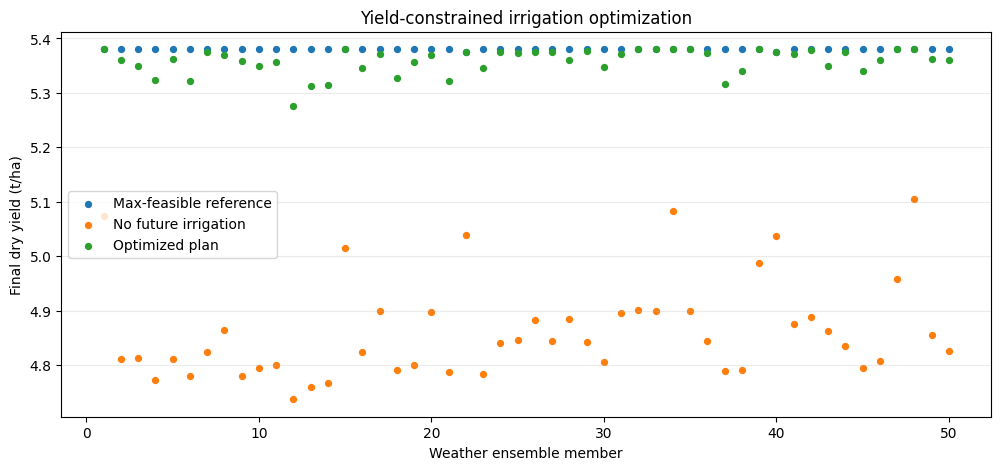

In [24]:
# --- Yield optimizer diagnostics ---
if yield_plan is not None:
    import matplotlib.pyplot as plt

    members = sorted(yield_plan.reference_yields_t_ha)
    ref = np.array([yield_plan.reference_yields_t_ha[m] for m in members])
    no_irr = np.array([yield_plan.no_irrigation_evaluation.member_yield_t_ha[m] for m in members])
    optimized = np.array([yield_plan.optimized_evaluation.member_yield_t_ha[m] for m in members])

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(members, ref, s=18, label="Max-feasible reference")
    ax.scatter(members, no_irr, s=18, label="No future irrigation")
    ax.scatter(members, optimized, s=18, label="Optimized plan")
    ax.set_xlabel("Weather ensemble member")
    ax.set_ylabel("Final dry yield (t/ha)")
    ax.set_title("Yield-constrained irrigation optimization")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.show()


---
## Block 6c — Retrospective irrigation optimization

For a completed season, recorded irrigation **dates stay fixed** and only their doses are
allowed to change; a zero dose means the event could have been omitted. The reference is the
final dry yield produced by the farmer's recorded schedule under the same observed weather.
The search therefore answers: *how much water could have been removed without materially
changing harvest yield?*

In [7]:
%%capture

historical_yield_optimization = None
RUN_HISTORICAL_OPTIMIZER = True
HISTORICAL_PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}.yaml"
HISTORICAL_PARCEL_CONFIG2 = f"configs/parcels/guide_{TODAY.year}.yaml"

if RUN_HISTORICAL_OPTIMIZER:
    import xarray as xr
    import pandas as pd
    from irrigator.config import load_parcel_config
    from irrigator.static_layers.soil import get_soil_profile
    from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation
    from irrigator.atmospheric.forcing import extract_parcel_forcing
    from irrigator.water_balance.yield_optimizer import (
        YieldConstraint,
        optimize_historical_irrigation_amounts,
    )
    from irrigator.config import load_region_config, load_parcel_config

    cfg = load_region_config(REGION_CONFIG)

    parcel_hist = load_parcel_config(HISTORICAL_PARCEL_CONFIG)
    parcel_hist2 = load_parcel_config(HISTORICAL_PARCEL_CONFIG2)

    hist_year = pd.Timestamp(parcel_hist.crop["planting_date"]).year
    hist_start = date(hist_year, 1, 1)
    hist_end = pd.Timestamp(parcel_hist.crop["expected_harvest"]).date()

    terrain_hist = get_terrain_params(cfg, parcel_hist)
    terrain_hist.era5_elevation_m = get_era5_elevation(cfg, parcel_hist)
    soil_hist = get_soil_profile(cfg, parcel_hist)

    terrain_hist2 = get_terrain_params(cfg, parcel_hist2)
    terrain_hist2.era5_elevation_m = get_era5_elevation(cfg, parcel_hist2)
    soil_hist2 = get_soil_profile(cfg, parcel_hist2)

    era5_hist = xr.open_dataset(PROCESSED_DIR / "atmospheric" / f"era5_daily_{hist_year}.nc")
    forcing_hist = extract_parcel_forcing(era5_hist, parcel_hist, terrain_hist).slice(
        hist_start, hist_end
    )
    forcing_hist2 = extract_parcel_forcing(era5_hist, parcel_hist2, terrain_hist2).slice(
            hist_start, hist_end
        )
    from irrigator.water_balance.soil_water_content import (
        build_initial_soil_water_profile_from_era5_land,
    )

    historical_initial_soil_water_parcel = build_initial_soil_water_profile_from_era5_land(
        soil_profile=soil_hist,
        parcel_profile=parcel_hist,
        date=hist_start,
        processed_dir=PROCESSED_DIR,
        raw_dir=RAW_DIR,
        static_dir=STATIC_DIR,
    )

    historical_initial_soil_water_parcel2 = build_initial_soil_water_profile_from_era5_land(
            soil_profile=soil_hist2,
            parcel_profile=parcel_hist2,
            date=hist_start,
            processed_dir=PROCESSED_DIR,
            raw_dir=RAW_DIR,
            static_dir=STATIC_DIR,
        )


    historical_yield_optimization = optimize_historical_irrigation_amounts(
        observed_forcing=forcing_hist,
        parcel=parcel_hist,
        terrain=terrain_hist,
        soil_profile=soil_hist,
        sim_start=hist_start,
        sim_end=hist_end,
        constraint=YieldConstraint(
            max_relative_loss=0.005,  # <=0.5% vs the recorded schedule
            min_member_probability=1.0,  # deterministic historical weather
            absolute_tolerance_t_ha=0.01,
        ),
        dose_resolution_mm=1.0,
        max_passes=3,
        initial_soil_water_profile=historical_initial_soil_water_parcel,
    )

    historical_yield_optimization2 = optimize_historical_irrigation_amounts(
            observed_forcing=forcing_hist2,
            parcel=parcel_hist2,
            terrain=terrain_hist2,
            soil_profile=soil_hist2,
            sim_start=hist_start,
            sim_end=hist_end,
            constraint=YieldConstraint(
                max_relative_loss=0.005,  # <=0.5% vs the recorded schedule
                min_member_probability=1.0,  # deterministic historical weather
                absolute_tolerance_t_ha=0.01,
            ),
            dose_resolution_mm=1.0,
            max_passes=3,
            initial_soil_water_profile=historical_initial_soil_water_parcel2,
        )

    print(f"Recorded irrigation:  {historical_yield_optimization.original_mm:.1f} mm")
    print(f"Optimized irrigation: {historical_yield_optimization.optimized_mm:.1f} mm")
    print(
        f"Potential saving:      {historical_yield_optimization.saved_mm:.1f} mm "
        f"({historical_yield_optimization.saved_fraction:.1%})"
    )
    display(historical_yield_optimization.to_dataframe())
    print(f"Recorded irrigation:  {historical_yield_optimization2.original_mm:.1f} mm")
    print(f"Optimized irrigation: {historical_yield_optimization2.optimized_mm:.1f} mm")
    print(
        f"Potential saving:      {historical_yield_optimization2.saved_mm:.1f} mm "
        f"({historical_yield_optimization2.saved_fraction:.1%})"
    )
    display(historical_yield_optimization2.to_dataframe())
else:
    print("Historical optimizer skipped (set RUN_HISTORICAL_OPTIMIZER=True)")


15:26:39 [irrigator.static_layers.terrain] INFO: Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
15:26:39 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask


15:26:46 [irrigator.static_layers.soil] INFO: Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
15:26:46 [irrigator.static_layers.terrain] INFO: Parcel guide_001 terrain: elev=141 m, slope=3.3°, aspect=282°
15:26:46 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask
15:26:53 [irrigator.static_layers.soil] INFO: Parcel guide_001: using EU-SoilHydroGrids — AWC=249 mm, FC=[0.360, 0.350, 0.340, 0.340, 0.331, 0.317]
15:26:53 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
15:26:53 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
15:26:53 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 365 days, T=[-4.0, 39.0]°C, total precip=nan mm, mean Rs=nan MJ/m²/day
15:26:53 [irrigator.atmospheric.forcing] INFO: Parcel guide_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
15:26:53 [irrigator.atmospheric.forc

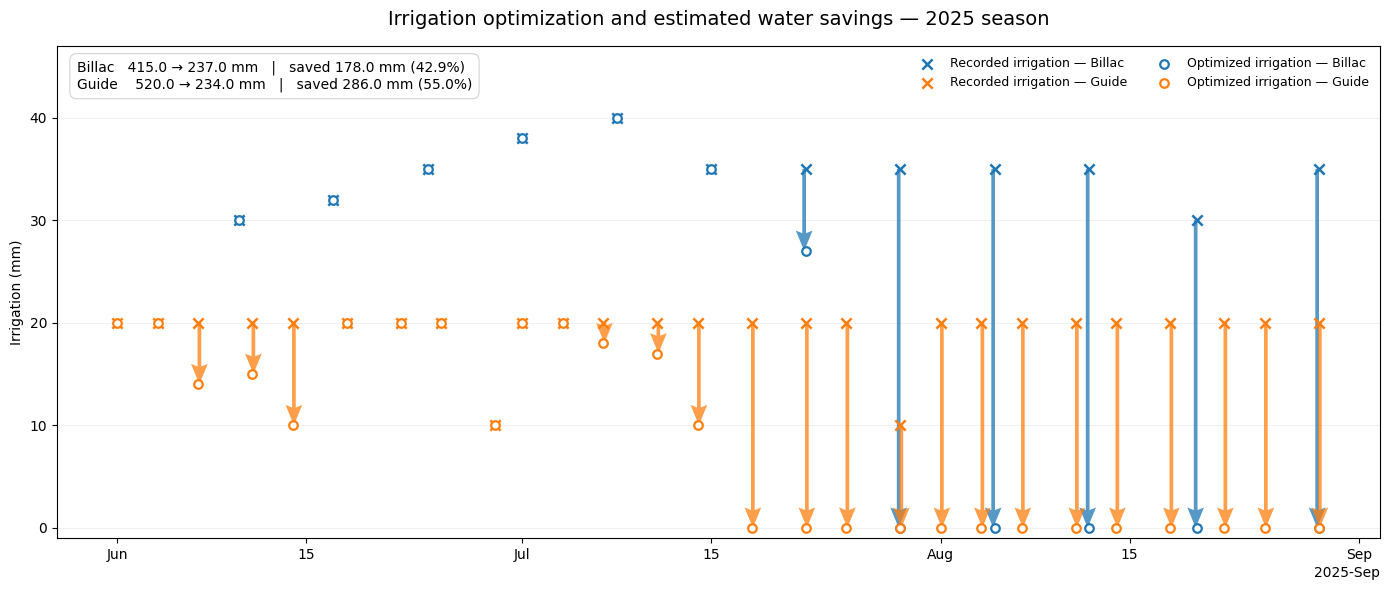

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

optimization = historical_yield_optimization.to_dataframe().copy()
optimization2 = historical_yield_optimization2.to_dataframe().copy()

optimization["date"] = pd.to_datetime(optimization["date"])
optimization2["date"] = pd.to_datetime(optimization2["date"])

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
BILLAC_COLOR = "C0"  # muted blue
GUIDE_COLOR = "C1"  # muted green
TEXT_COLOR = "black"

fig, ax = plt.subplots(figsize=(14, 6))

# matplotlib dates are internally expressed as days
x1 = mdates.date2num(optimization["date"])
x2 = mdates.date2num(optimization2["date"])

# Small horizontal separation so the two arrows sit side-by-side
# Adjust depending on how dense your irrigation dates are.
arrow_offset = 0.10  # days = 2.4 hours

# ---------------------------------------------------------------------
# Recorded irrigation
# ---------------------------------------------------------------------
ax.scatter(
    optimization["date"],
    optimization["recorded_mm"],
    label="Recorded irrigation — Billac",
    marker="x",
    s=55,
    linewidth=1.8,
    color=BILLAC_COLOR,
    zorder=4,
)

ax.scatter(
    optimization2["date"],
    optimization2["recorded_mm"],
    label="Recorded irrigation — Guide",
    marker="x",
    s=55,
    linewidth=1.8,
    color=GUIDE_COLOR,
    zorder=4,
)

# ---------------------------------------------------------------------
# Optimized irrigation
# ---------------------------------------------------------------------
ax.scatter(
    optimization["date"],
    optimization["optimized_mm"],
    label="Optimized irrigation — Billac",
    marker="o",
    s=38,
    facecolor="white",
    edgecolor=BILLAC_COLOR,
    linewidth=1.6,
    zorder=5,
)

ax.scatter(
    optimization2["date"],
    optimization2["optimized_mm"],
    label="Optimized irrigation — Guide",
    marker="o",
    s=38,
    facecolor="white",
    edgecolor=GUIDE_COLOR,
    linewidth=1.6,
    zorder=5,
)

# ---------------------------------------------------------------------
# Water-saving arrows
#
# Billac = left side
# Guide  = right side
# ---------------------------------------------------------------------
billac_delta = optimization["optimized_mm"].to_numpy() - optimization["recorded_mm"].to_numpy()

guide_delta = optimization2["optimized_mm"].to_numpy() - optimization2["recorded_mm"].to_numpy()

ax.quiver(
    x1 - arrow_offset,
    optimization["recorded_mm"].to_numpy(),
    np.zeros(len(optimization)),
    billac_delta,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.0028,
    headwidth=4.5,
    headlength=5.5,
    headaxislength=4.8,
    color=BILLAC_COLOR,
    alpha=0.75,
    zorder=2,
)

ax.quiver(
    x2 + arrow_offset,
    optimization2["recorded_mm"].to_numpy(),
    np.zeros(len(optimization2)),
    guide_delta,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.0028,
    headwidth=4.5,
    headlength=5.5,
    headaxislength=4.8,
    color=GUIDE_COLOR,
    alpha=0.75,
    zorder=2,
)

# ---------------------------------------------------------------------
# Summary box
# ---------------------------------------------------------------------
textstr = "\n".join(
    (
        (
            f"Billac   "
            f"{historical_yield_optimization.original_mm:.1f} → "
            f"{historical_yield_optimization.optimized_mm:.1f} mm   |   "
            f"saved {historical_yield_optimization.saved_mm:.1f} mm "
            f"({historical_yield_optimization.saved_fraction:.1%})"
        ),
        (
            f"Guide    "
            f"{historical_yield_optimization2.original_mm:.1f} → "
            f"{historical_yield_optimization2.optimized_mm:.1f} mm   |   "
            f"saved {historical_yield_optimization2.saved_mm:.1f} mm "
            f"({historical_yield_optimization2.saved_fraction:.1%})"
        ),
    )
)

ax.text(
    0.015,
    0.97,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    color=TEXT_COLOR,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#D0D0D0",
        linewidth=0.8,
        alpha=0.95,
    ),
)

# ---------------------------------------------------------------------
# Axes / presentation
# ---------------------------------------------------------------------
ax.set_title(
    "Irrigation optimization and estimated water savings — 2025 season",
    fontsize=14,
    pad=15,
)

ax.set_ylabel("Irrigation (mm)")
ax.set_xlabel("")

ax.set_ylim(
    -1,
    max(
        optimization["recorded_mm"].max(),
        optimization2["recorded_mm"].max(),
    )
    + 7,
)

# Cleaner date formatting
locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# Light horizontal grid only
ax.grid(
    axis="y",
    linewidth=0.6,
    alpha=0.2,
)

ax.legend(
    ncol=2,
    frameon=False,
    loc="upper right",
    fontsize=9,
)

fig.tight_layout()
plt.show()


---
## Block 6d — Retrospective irrigation optimization - comparison of the forecast pipeline to optimal strategy

For a completed season, recorded irrigation dates and their doses are
allowed to change. We simply test the optimization pipeline and compare it to the maximum water savings. 

---
## Summary: data flow

```
ERA5-Land France-wide cache ──[Block 2: extract + downscale]──→ DailyForcing (parcel)
                                                                       │
                                                      [Blocks 3+4: simulation]──→ current_state
                                                                                        │
AROME France-wide cache ──[extract + downscale]──→ DailyForcing (parcel)                │
                                                         │                              │
IFS ENS download ──[process daily]──[extract]──→ 51× DailyForcing (parcel)              │
                                                         │                              │
                                              [Block 5a: ensemble forward balance]──────┤
                                                                                        │
SEAS5 ──[bias correct]──[PCA analog]──[extract]──→ N× DailyForcing                     │
                                                         │                              │
                                              [Block 5b: seasonal water balance]────────┤
                                                                                        │
                                              [Block 6: decision rules]─────→ IrrigationAdvice
```

All gridded data sources (ERA5-Land, AROME, IFS ENS, SEAS5 analogs) are France-wide.
Parcel extraction happens once through `extract_parcel_forcing()` — one function,
one set of corrections (lapse rate, radiation, wind), for all sources.